In [1]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="ibm-nasa-geospatial/hls_burn_scars",
    repo_type="dataset",
    local_dir="/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars"
)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

'/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars'

In [2]:
import os

data_dir = "/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars"

all_files = os.listdir(data_dir)
print(f"Total files: {len(all_files)}")
print("\nFirst 10 files:")
for f in all_files[:10]:
    print(f)

Total files: 5

First 10 files:
README.md
.gitattributes
hls_burn_scars.py
.cache
hls_burn_scars.tar.gz


In [3]:
import tarfile

tar_path = "/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars/hls_burn_scars.tar.gz"
extract_path = "/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars"

print("Extracting... this may take a few minutes")
with tarfile.open(tar_path, 'r:gz') as tar:
    tar.extractall(extract_path)

print("Done! Let's see what we got:")
files = os.listdir(extract_path)
print(f"Total items: {len(files)}")
for f in files[:15]:
    print(f)

Extracting... this may take a few minutes
Done! Let's see what we got:
Total items: 7
training
README.md
.gitattributes
hls_burn_scars.py
.cache
hls_burn_scars.tar.gz
validation


In [4]:
train_dir = "/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars/training"
val_dir   = "/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars/validation"

train_files = os.listdir(train_dir)
val_files   = os.listdir(val_dir)

print(f"Training files:   {len(train_files)}")
print(f"Validation files: {len(val_files)}")
print("\nSample training files:")
for f in sorted(train_files)[:10]:
    print(f)

Training files:   1081
Validation files: 529

Sample training files:
subsetted_512x512_HLS.S30.T10SDH.2020248.v1.4.mask.tif
subsetted_512x512_HLS.S30.T10SDH.2020248.v1.4_merged.tif
subsetted_512x512_HLS.S30.T10SEH.2018245.v1.4.mask.tif
subsetted_512x512_HLS.S30.T10SEH.2018245.v1.4_merged.tif
subsetted_512x512_HLS.S30.T10SEH.2018280.v1.4.mask.tif
subsetted_512x512_HLS.S30.T10SEH.2018280.v1.4_merged.tif
subsetted_512x512_HLS.S30.T10SEH.2019305.v1.4.mask.tif
subsetted_512x512_HLS.S30.T10SEH.2019305.v1.4_merged.tif
subsetted_512x512_HLS.S30.T10SEH.2020190.v1.4.mask.tif
subsetted_512x512_HLS.S30.T10SEH.2020190.v1.4_merged.tif


Input shape:  (6, 512, 512)
Input bands:  6
Input dtype:  ('float32', 'float32', 'float32', 'float32', 'float32', 'float32')
Value range:  0 to 0

Mask shape:   (512, 512)
Mask unique values: [-1.  0.  1.]


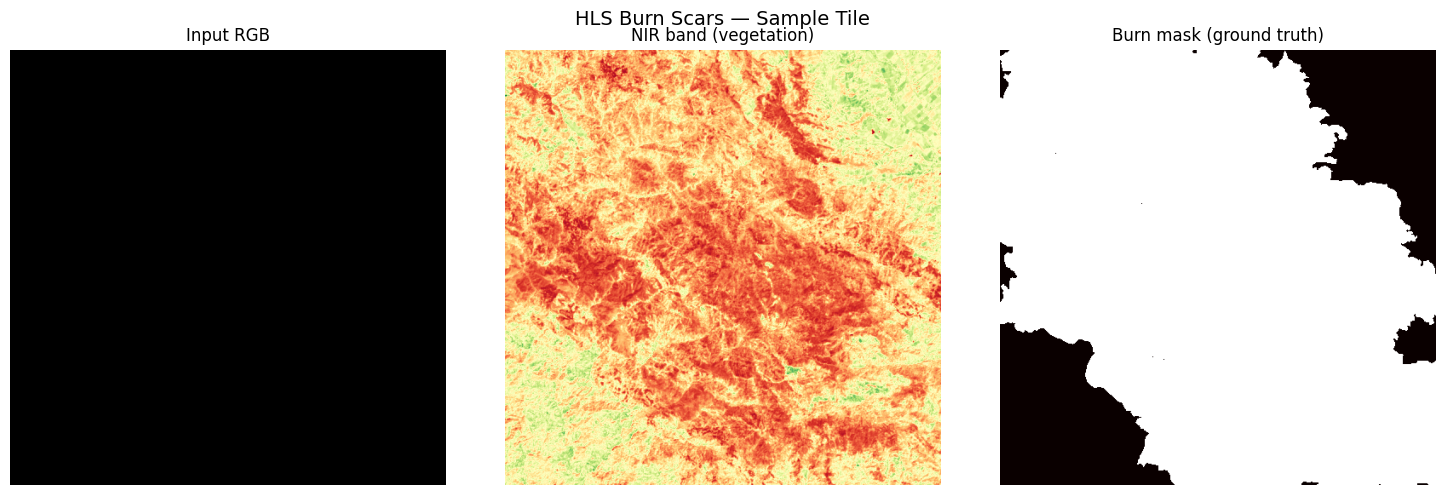

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

train_dir = "/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars/training"

# Load one input/mask pair
input_path = f"{train_dir}/subsetted_512x512_HLS.S30.T10SDH.2020248.v1.4_merged.tif"
mask_path  = f"{train_dir}/subsetted_512x512_HLS.S30.T10SDH.2020248.v1.4.mask.tif"

with rasterio.open(input_path) as src:
    img = src.read().astype(np.float32)   # (6, 512, 512)
    print(f"Input shape:  {img.shape}")
    print(f"Input bands:  {src.count}")
    print(f"Input dtype:  {src.dtypes}")
    print(f"Value range:  {img.min():.0f} to {img.max():.0f}")

with rasterio.open(mask_path) as src:
    mask = src.read(1).astype(np.float32)  # (512, 512)
    print(f"\nMask shape:   {mask.shape}")
    print(f"Mask unique values: {np.unique(mask)}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RGB composite (bands 2,1,0 = Red, Green, Blue)
rgb = img[[2,1,0]].transpose(1,2,0)
rgb = np.clip(rgb / 3000.0, 0, 1)  # HLS values are 0-10000, brighten for display
axes[0].imshow(rgb)
axes[0].set_title('Input RGB')
axes[0].axis('off')

# NIR band (band index 3)
axes[1].imshow(img[3], cmap='RdYlGn')
axes[1].set_title('NIR band (vegetation)')
axes[1].axis('off')

# Burn mask
axes[2].imshow(mask, cmap='hot', vmin=0, vmax=1)
axes[2].set_title('Burn mask (ground truth)')
axes[2].axis('off')

plt.suptitle('HLS Burn Scars — Sample Tile', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
import glob

train_inputs = sorted(glob.glob(f"{train_dir}/*_merged.tif"))
print(f"Total training input tiles: {len(train_inputs)}")

# Check value ranges across first 5 tiles
for path in train_inputs[:5]:
    with rasterio.open(path) as src:
        data = src.read().astype(np.float32)
        print(f"{os.path.basename(path)[:50]}  min={data.min():.4f}  max={data.max():.4f}  mean={data.mean():.4f}")

Total training input tiles: 540
subsetted_512x512_HLS.S30.T10SDH.2020248.v1.4_merg  min=0.0000  max=0.4514  mean=0.0853
subsetted_512x512_HLS.S30.T10SEH.2018245.v1.4_merg  min=0.0000  max=1.0000  mean=0.1647
subsetted_512x512_HLS.S30.T10SEH.2018280.v1.4_merg  min=0.0010  max=0.5458  mean=0.1142
subsetted_512x512_HLS.S30.T10SEH.2019305.v1.4_merg  min=0.0000  max=0.5720  mean=0.1140
subsetted_512x512_HLS.S30.T10SEH.2020190.v1.4_merg  min=0.0000  max=0.9816  mean=0.1651


In [7]:
import sys
sys.path.insert(0, '/Users/leonardofloresgonzalez/wildfire_project/src')

from dataset import HLSBurnScarsDataset
from torch.utils.data import DataLoader

train_ds = HLSBurnScarsDataset(
    '/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars/training'
)

batch = next(iter(DataLoader(train_ds, batch_size=2)))
print(f"Image shape: {batch['image'].shape}")  # expect (2, 6, 1, 512, 512)
print(f"Mask shape:  {batch['mask'].shape}")   # expect (2, 512, 512)
print(f"Mask unique: {batch['mask'].unique()}")  # expect tensor([-1, 0, 1])

Dataset: 540 valid input/mask pairs found in training
Image shape: torch.Size([2, 6, 1, 512, 512])
Mask shape:  torch.Size([2, 512, 512])
Mask unique: tensor([-1,  0,  1])


In [8]:
import sys
sys.path.insert(0, '/Users/leonardofloresgonzalez/wildfire_project/src')

import torch
import warnings
warnings.filterwarnings('ignore', message='.*HF_TOKEN.*')

from model import build_prithvi_task

# Build model
task = build_prithvi_task(freeze_backbone=True)
print('Model built successfully')

# Test one forward pass
device = (
    'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')

task.to(device)
task.eval()

# Fake batch matching our dataset shape
dummy = torch.randn(2, 6, 1, 512, 512).to(device)

with torch.no_grad():
    output = task.model(dummy)

print(f'Output shape: {output.output.shape}')  # expect (2, 2, 512, 512)
print('Forward pass successful!')

2026-04-17 13:25:20,210 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M/resolve/main/Prithvi_EO_V2_300M.pt "HTTP/1.1 302 Found"
2026-04-17 13:25:20,305 - INFO - HTTP Request: GET https://huggingface.co/api/models/ibm-nasa-geospatial/Prithvi-EO-2.0-300M/xet-read-token/9eb1b1102806593963daa333bcc491b1c6f8562f "HTTP/1.1 200 OK"


Prithvi_EO_V2_300M.pt:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

2026-04-17 13:25:40,028 - INFO - Loaded weights for HLSBands.BLUE in position 0 of patch embed
2026-04-17 13:25:40,033 - INFO - Loaded weights for HLSBands.GREEN in position 1 of patch embed
2026-04-17 13:25:40,033 - INFO - Loaded weights for HLSBands.RED in position 2 of patch embed
2026-04-17 13:25:40,034 - INFO - Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
2026-04-17 13:25:40,034 - INFO - Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
2026-04-17 13:25:40,034 - INFO - Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed
/opt/homebrew/Caskroom/miniforge/base/envs/wildfire/lib/python3.11/site-packages/terratorch/models/necks.py:367: UserWarning: MPS backend: enforcing .contiguous() to avoid non‑contiguous tensor issues on M‑series chips; may cause extra copies and slower execution.
  warnings.warn(


Model built successfully
Using device: mps
Output shape: torch.Size([2, 2, 512, 512])
Forward pass successful!


In [10]:
from dataset import HLSBurnScarsDataset
from model import build_prithvi_task
from torch.utils.data import DataLoader, Subset
import pytorch_lightning as pl
import terratorch.tasks

# Use only 20 training samples and 10 val samples for the smoke test
train_ds = HLSBurnScarsDataset(
    '/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars/training',
    augment=False
)
val_ds = HLSBurnScarsDataset(
    '/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars/validation',
    augment=False
)

train_subset = Subset(train_ds, range(20))
val_subset   = Subset(val_ds,   range(10))

train_loader = DataLoader(train_subset, batch_size=2, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_subset,   batch_size=2, shuffle=False, num_workers=0)

# Build task
task = build_prithvi_task(freeze_backbone=True)

# Check it is actually a LightningModule
print(f'Is LightningModule: {isinstance(task, pl.LightningModule)}')
print(f'Task type: {type(task)}')
print(f'MRO: {[c.__name__ for c in type(task).__mro__]}')

Dataset: 540 valid input/mask pairs found in training
Dataset: 264 valid input/mask pairs found in validation


2026-04-17 13:30:36,330 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M/resolve/main/Prithvi_EO_V2_300M.pt "HTTP/1.1 302 Found"
2026-04-17 13:30:37,085 - INFO - Loaded weights for HLSBands.BLUE in position 0 of patch embed
2026-04-17 13:30:37,088 - INFO - Loaded weights for HLSBands.GREEN in position 1 of patch embed
2026-04-17 13:30:37,088 - INFO - Loaded weights for HLSBands.RED in position 2 of patch embed
2026-04-17 13:30:37,089 - INFO - Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
2026-04-17 13:30:37,089 - INFO - Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
2026-04-17 13:30:37,090 - INFO - Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed


Is LightningModule: False
Task type: <class 'terratorch.tasks.segmentation_tasks.SemanticSegmentationTask'>
MRO: ['SemanticSegmentationTask', 'TerraTorchTask', 'BaseTask', 'LightningModule', '_DeviceDtypeModuleMixin', 'HyperparametersMixin', 'ModelHooks', 'DataHooks', 'CheckpointHooks', 'Module', 'ABC', 'object']


In [11]:
from lightning import Trainer, LightningModule

print(f'Is LightningModule: {isinstance(task, LightningModule)}')

Is LightningModule: True


In [13]:
from lightning import Trainer

trainer = Trainer(
    max_epochs=1,
    accelerator='mps',
    precision='32',
    log_every_n_steps=1,
    enable_checkpointing=False,
    logger=False,        # disable logger to avoid val_dataset error
)

print('Starting smoke test — 1 epoch on 20 samples...')
trainer.fit(task, train_loader, val_loader)
print('Smoke test passed!')

2026-04-17 13:33:32,413 - INFO - GPU available: True (mps), used: True
2026-04-17 13:33:32,413 - INFO - TPU available: False, using: 0 TPU cores
2026-04-17 13:33:32,414 - INFO - 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Starting smoke test — 1 epoch on 20 samples...


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  315 M │ eval │     0 │
│ 1 │ criterion     │ CrossEntropyLoss │      0 │ eval │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ eval │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ eval │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ eval │     0 │
└───┴───────────────┴──────────────────┴────────┴──────┴───────┘

Trainable params: 11.3 M                                                                                           
Non-trainable params: 303 M                                                                                        
Total params: 315 M                                                                                                
Total estimated model params size (MB): 1.3 K                                                                      
Modules in train mode: 0                                                                                           
Modules in eval mode: 647                                                                                          
Total FLOPs: 0

Output()

/opt/homebrew/Caskroom/miniforge/base/envs/wildfire/lib/python3.11/site-packages/lightning/pytorch/trainer/connecto
rs/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

/opt/homebrew/Caskroom/miniforge/base/envs/wildfire/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.p
y:534: Found 648 module(s) in eval mode at the start of training. This may lead to unexpected behavior during 
training. If this is intentional, you can ignore this warning.

/opt/homebrew/Caskroom/miniforge/base/envs/wildfire/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:4
3: UserWarning: The ``compute`` method of metric MulticlassAccuracy was called before the ``update`` method which 
may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

2026-04-17 13:33:47,509 - INFO - `Trainer.fit` stopped: `max_epochs=1` reached.


Smoke test passed!


In [14]:
import sys
sys.path.insert(0, '/Users/leonardofloresgonzalez/wildfire_project/src')

# Reload modules in case they were cached from earlier
import importlib
import dataset, model
importlib.reload(dataset)
importlib.reload(model)

from dataset import HLSBurnScarsDataset
from model import build_prithvi_task

print('All source files import cleanly')

# Quick check — dataset still works
ds = HLSBurnScarsDataset(
    '/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars/training'
)
print(f'Training samples: {len(ds)}')

All source files import cleanly
Dataset: 540 valid input/mask pairs found in training
Training samples: 540


In [15]:
import sys
sys.path.insert(0, '/Users/leonardofloresgonzalez/wildfire_project/src')

import torch
import warnings
warnings.filterwarnings('ignore')

from model import build_prithvi_task

weights_path = '/Users/leonardofloresgonzalez/wildfire_project/checkpoints/wildfire_weights.pt'

task = build_prithvi_task(freeze_backbone=False)
task.model.load_state_dict(
    torch.load(weights_path, map_location='cpu')
)
task.eval()
print('Model loaded successfully')

2026-04-17 14:23:32,360 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M/resolve/main/Prithvi_EO_V2_300M.pt "HTTP/1.1 302 Found"
2026-04-17 14:23:33,039 - INFO - Loaded weights for HLSBands.BLUE in position 0 of patch embed
2026-04-17 14:23:33,046 - INFO - Loaded weights for HLSBands.GREEN in position 1 of patch embed
2026-04-17 14:23:33,046 - INFO - Loaded weights for HLSBands.RED in position 2 of patch embed
2026-04-17 14:23:33,048 - INFO - Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
2026-04-17 14:23:33,048 - INFO - Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
2026-04-17 14:23:33,050 - INFO - Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed


Model loaded successfully


Using device: mps
Running inference on: subsetted_512x512_HLS.S30.T10SEH.2018190.v1.4_merged.tif


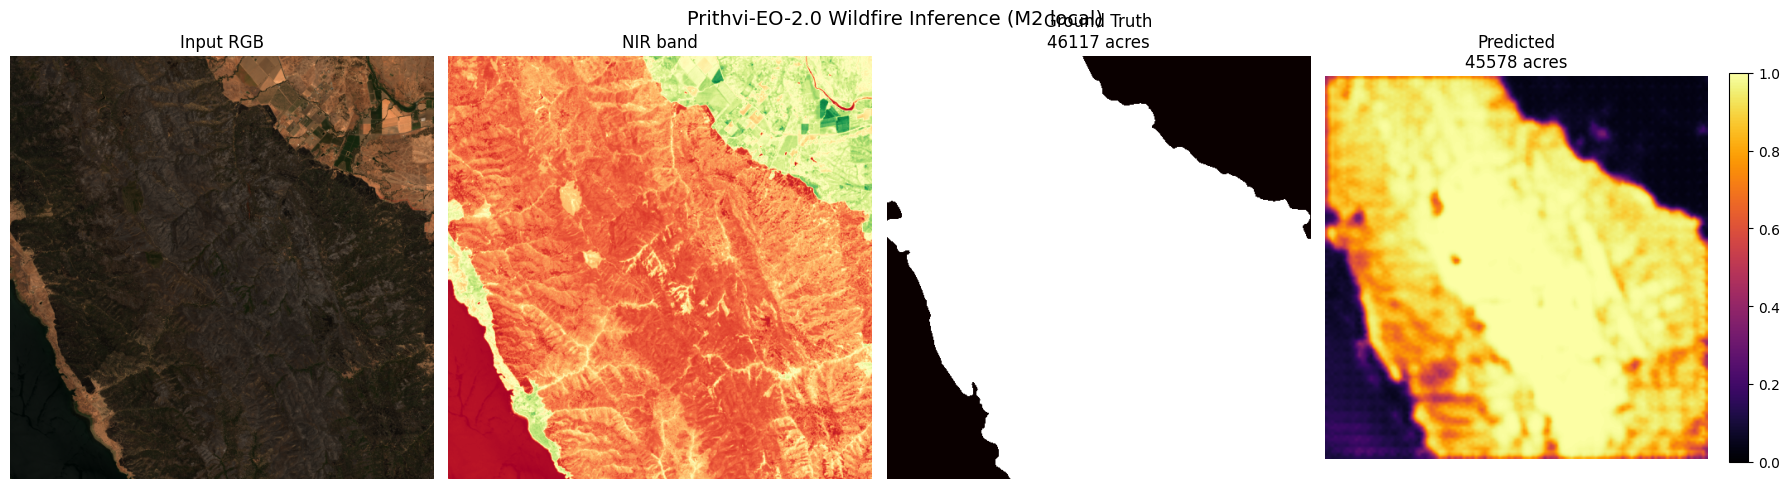

Ground truth:  46117 acres
Predicted:     45578 acres


In [16]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import glob
import os

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')
task.to(device)

# Pick a validation tile
val_dir = '/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars/validation'
sample_input = sorted(glob.glob(f'{val_dir}/*_merged.tif'))[0]
sample_mask  = sample_input.replace('_merged.tif', '.mask.tif')
print(f'Running inference on: {os.path.basename(sample_input)}')

# Load and preprocess
with rasterio.open(sample_input) as src:
    img = src.read().astype(np.float32)   # (6, H, W)
with rasterio.open(sample_mask) as src:
    gt_mask = src.read(1).astype(np.float32)  # ground truth

img = np.clip(img, 0, 1)
img = np.nan_to_num(img, nan=0.0)
img = img[:, np.newaxis, :, :]   # (6, 1, H, W)

tensor = torch.tensor(img).unsqueeze(0).to(device)  # (1, 6, 1, H, W)

# Inference
with torch.no_grad():
    output = task.model(tensor)
    probs  = output.output.softmax(dim=1)[0, 1].cpu().numpy()
    pred_mask = output.output.argmax(dim=1)[0].cpu().numpy()

# Fire size estimate
burned_pixels   = (pred_mask == 1).sum()
predicted_acres = burned_pixels * 900 / 4047
actual_acres    = (gt_mask == 1).sum() * 900 / 4047

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

rgb = img[[2,1,0], 0].transpose(1,2,0)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
axes[0].imshow(rgb)
axes[0].set_title('Input RGB')
axes[0].axis('off')

axes[1].imshow(img[3, 0], cmap='RdYlGn')
axes[1].set_title('NIR band')
axes[1].axis('off')

axes[2].imshow(gt_mask, cmap='hot', vmin=0, vmax=1)
axes[2].set_title(f'Ground Truth\n{actual_acres:.0f} acres')
axes[2].axis('off')

im = axes[3].imshow(probs, cmap='inferno', vmin=0, vmax=1)
axes[3].set_title(f'Predicted\n{predicted_acres:.0f} acres')
axes[3].axis('off')
plt.colorbar(im, ax=axes[3], fraction=0.046)

plt.suptitle('Prithvi-EO-2.0 Wildfire Inference (M2 local)', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Ground truth:  {actual_acres:.0f} acres')
print(f'Predicted:     {predicted_acres:.0f} acres')

In [17]:
# Run inference on first 6 validation tiles and compare
val_inputs = sorted(glob.glob(f'{val_dir}/*_merged.tif'))[:6]

results = []
for path in val_inputs:
    mask_path = path.replace('_merged.tif', '.mask.tif')

    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)
    with rasterio.open(mask_path) as src:
        gt = src.read(1).astype(np.float32)

    img = np.clip(img, 0, 1)
    img = np.nan_to_num(img, nan=0.0)
    img = img[:, np.newaxis, :, :]
    tensor = torch.tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = task.model(tensor)
        pred = output.output.argmax(dim=1)[0].cpu().numpy()

    actual    = (gt == 1).sum() * 900 / 4047
    predicted = (pred == 1).sum() * 900 / 4047
    error_pct = abs(actual - predicted) / (actual + 1e-6) * 100

    results.append({
        'file':      os.path.basename(path)[:40],
        'actual':    actual,
        'predicted': predicted,
        'error_%':   error_pct
    })
    print(f'{os.path.basename(path)[:45]}')
    print(f'  Actual: {actual:>8.0f} acres | Predicted: {predicted:>8.0f} acres | Error: {error_pct:.1f}%')
    print()

import pandas as pd
df = pd.DataFrame(results)
print(f'Mean absolute error: {df["error_%"].mean():.1f}%')
print(f'Best:  {df["error_%"].min():.1f}%')
print(f'Worst: {df["error_%"].max():.1f}%')

subsetted_512x512_HLS.S30.T10SEH.2018190.v1.4
  Actual:    46117 acres | Predicted:    45578 acres | Error: 1.2%

subsetted_512x512_HLS.S30.T10SFE.2021166.v1.4
  Actual:     1232 acres | Predicted:     1183 acres | Error: 4.0%

subsetted_512x512_HLS.S30.T10SFF.2020215.v1.4
  Actual:     1559 acres | Predicted:     1623 acres | Error: 4.1%

subsetted_512x512_HLS.S30.T10SFG.2020185.v1.4
  Actual:     2248 acres | Predicted:     2836 acres | Error: 26.2%

subsetted_512x512_HLS.S30.T10SFG.2020215.v1.4
  Actual:     5796 acres | Predicted:     4866 acres | Error: 16.0%

subsetted_512x512_HLS.S30.T10SGD.2018257.v1.4
  Actual:     1128 acres | Predicted:     1477 acres | Error: 30.9%

Mean absolute error: 13.7%
Best:  1.2%
Worst: 30.9%


In [18]:
import importlib
import model
importlib.reload(model)
from model import build_prithvi_task

# Reload with class weights
task = build_prithvi_task(freeze_backbone=False)
task.model.load_state_dict(
    torch.load(weights_path, map_location='cpu')
)
task.eval()
task.to(device)
print('Model reloaded with class weights')

2026-04-17 19:48:16,210 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M/resolve/main/Prithvi_EO_V2_300M.pt "HTTP/1.1 302 Found"
2026-04-17 19:48:17,029 - INFO - Loaded weights for HLSBands.BLUE in position 0 of patch embed
2026-04-17 19:48:17,048 - INFO - Loaded weights for HLSBands.GREEN in position 1 of patch embed
2026-04-17 19:48:17,050 - INFO - Loaded weights for HLSBands.RED in position 2 of patch embed
2026-04-17 19:48:17,050 - INFO - Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
2026-04-17 19:48:17,051 - INFO - Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
2026-04-17 19:48:17,052 - INFO - Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed


Model reloaded with class weights


In [19]:
val_inputs = sorted(glob.glob(f'{val_dir}/*_merged.tif'))[:6]

for path in val_inputs:
    mask_path = path.replace('_merged.tif', '.mask.tif')

    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)
    with rasterio.open(mask_path) as src:
        gt = src.read(1).astype(np.float32)

    img = np.clip(img, 0, 1)
    img = np.nan_to_num(img, nan=0.0)
    img = img[:, np.newaxis, :, :]
    tensor = torch.tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = task.model(tensor)
        pred = output.output.argmax(dim=1)[0].cpu().numpy()

    actual    = (gt == 1).sum() * 900 / 4047
    predicted = (pred == 1).sum() * 900 / 4047
    error_pct = abs(actual - predicted) / (actual + 1e-6) * 100

    print(f'{os.path.basename(path)[:45]}')
    print(f'  Actual: {actual:>8.0f} acres | Predicted: {predicted:>8.0f} acres | Error: {error_pct:.1f}%')
    print()

subsetted_512x512_HLS.S30.T10SEH.2018190.v1.4
  Actual:    46117 acres | Predicted:    45578 acres | Error: 1.2%

subsetted_512x512_HLS.S30.T10SFE.2021166.v1.4
  Actual:     1232 acres | Predicted:     1183 acres | Error: 4.0%

subsetted_512x512_HLS.S30.T10SFF.2020215.v1.4
  Actual:     1559 acres | Predicted:     1623 acres | Error: 4.1%

subsetted_512x512_HLS.S30.T10SFG.2020185.v1.4
  Actual:     2248 acres | Predicted:     2836 acres | Error: 26.2%

subsetted_512x512_HLS.S30.T10SFG.2020215.v1.4
  Actual:     5796 acres | Predicted:     4866 acres | Error: 16.0%

subsetted_512x512_HLS.S30.T10SGD.2018257.v1.4
  Actual:     1128 acres | Predicted:     1477 acres | Error: 30.9%



In [20]:
import sys
sys.path.insert(0, '/Users/leonardofloresgonzalez/wildfire_project/src')

import torch
import warnings
import importlib
import model
importlib.reload(model)
from model import build_prithvi_task

weights_path = '/Users/leonardofloresgonzalez/wildfire_project/checkpoints/wildfire_weights_final.pt'

task = build_prithvi_task(freeze_backbone=False)
task.model.load_state_dict(
    torch.load(weights_path, map_location='cpu')
)
task.eval()

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
task.to(device)
print(f'Model loaded on {device}')

2026-04-17 20:36:41,653 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M/resolve/main/Prithvi_EO_V2_300M.pt "HTTP/1.1 302 Found"
2026-04-17 20:36:42,427 - INFO - Loaded weights for HLSBands.BLUE in position 0 of patch embed
2026-04-17 20:36:42,435 - INFO - Loaded weights for HLSBands.GREEN in position 1 of patch embed
2026-04-17 20:36:42,435 - INFO - Loaded weights for HLSBands.RED in position 2 of patch embed
2026-04-17 20:36:42,436 - INFO - Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
2026-04-17 20:36:42,436 - INFO - Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
2026-04-17 20:36:42,437 - INFO - Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed


Model loaded on mps


In [21]:
import numpy as np
import rasterio
import glob
import os

val_dir = '/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars/validation'
val_inputs = sorted(glob.glob(f'{val_dir}/*_merged.tif'))[:6]

results = []
for path in val_inputs:
    mask_path = path.replace('_merged.tif', '.mask.tif')

    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)
    with rasterio.open(mask_path) as src:
        gt = src.read(1).astype(np.float32)

    img = np.clip(img, 0, 1)
    img = np.nan_to_num(img, nan=0.0)
    img = img[:, np.newaxis, :, :]
    tensor = torch.tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = task.model(tensor)
        pred = output.output.argmax(dim=1)[0].cpu().numpy()

    actual    = (gt == 1).sum() * 900 / 4047
    predicted = (pred == 1).sum() * 900 / 4047
    error_pct = abs(actual - predicted) / (actual + 1e-6) * 100

    results.append({
        'file':      os.path.basename(path)[:40],
        'actual':    actual,
        'predicted': predicted,
        'error_%':   error_pct
    })
    print(f'{os.path.basename(path)[:45]}')
    print(f'  Actual: {actual:>8.0f} acres | Predicted: {predicted:>8.0f} acres | Error: {error_pct:.1f}%')
    print()

import pandas as pd
df = pd.DataFrame(results)
print(f'Mean absolute error: {df["error_%"].mean():.1f}%')
print(f'Best:  {df["error_%"].min():.1f}%')
print(f'Worst: {df["error_%"].max():.1f}%')
print(f'\nv1 mean error: 13.7%')
print(f'v2 mean error: {df["error_%"].mean():.1f}%')

subsetted_512x512_HLS.S30.T10SEH.2018190.v1.4
  Actual:    46117 acres | Predicted:    38112 acres | Error: 17.4%

subsetted_512x512_HLS.S30.T10SFE.2021166.v1.4
  Actual:     1232 acres | Predicted:     1169 acres | Error: 5.2%

subsetted_512x512_HLS.S30.T10SFF.2020215.v1.4
  Actual:     1559 acres | Predicted:     1574 acres | Error: 1.0%

subsetted_512x512_HLS.S30.T10SFG.2020185.v1.4
  Actual:     2248 acres | Predicted:     2729 acres | Error: 21.4%

subsetted_512x512_HLS.S30.T10SFG.2020215.v1.4
  Actual:     5796 acres | Predicted:     4829 acres | Error: 16.7%

subsetted_512x512_HLS.S30.T10SGD.2018257.v1.4
  Actual:     1128 acres | Predicted:     1135 acres | Error: 0.6%

Mean absolute error: 10.4%
Best:  0.6%
Worst: 21.4%

v1 mean error: 13.7%
v2 mean error: 10.4%


In [22]:
import sys, torch, importlib
sys.path.insert(0, '/Users/leonardofloresgonzalez/wildfire_project/src')

import model
importlib.reload(model)
from model import build_prithvi_task

weights_path = '/Users/leonardofloresgonzalez/wildfire_project/checkpoints/wildfire_weights_v3_final.pt'

task = build_prithvi_task(freeze_backbone=False)
task.model.load_state_dict(
    torch.load(weights_path, map_location='cpu')
)
task.eval()

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
task.to(device)
print(f'v3 final model loaded on {device}')

2026-04-17 21:35:30,878 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M/resolve/main/Prithvi_EO_V2_300M.pt "HTTP/1.1 302 Found"
2026-04-17 21:35:31,593 - INFO - Loaded weights for HLSBands.BLUE in position 0 of patch embed
2026-04-17 21:35:31,599 - INFO - Loaded weights for HLSBands.GREEN in position 1 of patch embed
2026-04-17 21:35:31,601 - INFO - Loaded weights for HLSBands.RED in position 2 of patch embed
2026-04-17 21:35:31,603 - INFO - Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
2026-04-17 21:35:31,603 - INFO - Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
2026-04-17 21:35:31,604 - INFO - Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed


v3 final model loaded on mps


In [23]:
import numpy as np
import rasterio
import glob
import os
import pandas as pd

val_dir = '/Users/leonardofloresgonzalez/wildfire_project/data/hls_burn_scars/validation'
val_inputs = sorted(glob.glob(f'{val_dir}/*_merged.tif'))[:6]

results = []
for path in val_inputs:
    mask_path = path.replace('_merged.tif', '.mask.tif')

    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)
    with rasterio.open(mask_path) as src:
        gt = src.read(1).astype(np.float32)

    img = np.clip(img, 0, 1)
    img = np.nan_to_num(img, nan=0.0)
    img = img[:, np.newaxis, :, :]
    tensor = torch.tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = task.model(tensor)
        pred = output.output.argmax(dim=1)[0].cpu().numpy()

    actual    = (gt == 1).sum() * 900 / 4047
    predicted = (pred == 1).sum() * 900 / 4047
    error_pct = abs(actual - predicted) / (actual + 1e-6) * 100

    results.append({
        'file':      os.path.basename(path)[:40],
        'actual':    actual,
        'predicted': predicted,
        'error_%':   error_pct
    })
    print(f'{os.path.basename(path)[:45]}')
    print(f'  Actual: {actual:>8.0f} acres | Predicted: {predicted:>8.0f} acres | Error: {error_pct:.1f}%')
    print()

df = pd.DataFrame(results)
print('─' * 55)
print(f'v1 mean error:         13.7%  (no class weights)')
print(f'v2 mean error:         10.4%  (weights 1:3)')
print(f'v3 mean error:         {df["error_%"].mean():.1f}%  (weights 1:2, converged)')
print(f'Best:  {df["error_%"].min():.1f}%')
print(f'Worst: {df["error_%"].max():.1f}%')

subsetted_512x512_HLS.S30.T10SEH.2018190.v1.4
  Actual:    46117 acres | Predicted:    45733 acres | Error: 0.8%

subsetted_512x512_HLS.S30.T10SFE.2021166.v1.4
  Actual:     1232 acres | Predicted:     1185 acres | Error: 3.9%

subsetted_512x512_HLS.S30.T10SFF.2020215.v1.4
  Actual:     1559 acres | Predicted:     1643 acres | Error: 5.4%

subsetted_512x512_HLS.S30.T10SFG.2020185.v1.4
  Actual:     2248 acres | Predicted:     2282 acres | Error: 1.5%

subsetted_512x512_HLS.S30.T10SFG.2020215.v1.4
  Actual:     5796 acres | Predicted:     5260 acres | Error: 9.2%

subsetted_512x512_HLS.S30.T10SGD.2018257.v1.4
  Actual:     1128 acres | Predicted:     1161 acres | Error: 2.9%

───────────────────────────────────────────────────────
v1 mean error:         13.7%  (no class weights)
v2 mean error:         10.4%  (weights 1:3)
v3 mean error:         4.0%  (weights 1:2, converged)
Best:  0.8%
Worst: 9.2%
